# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [3]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

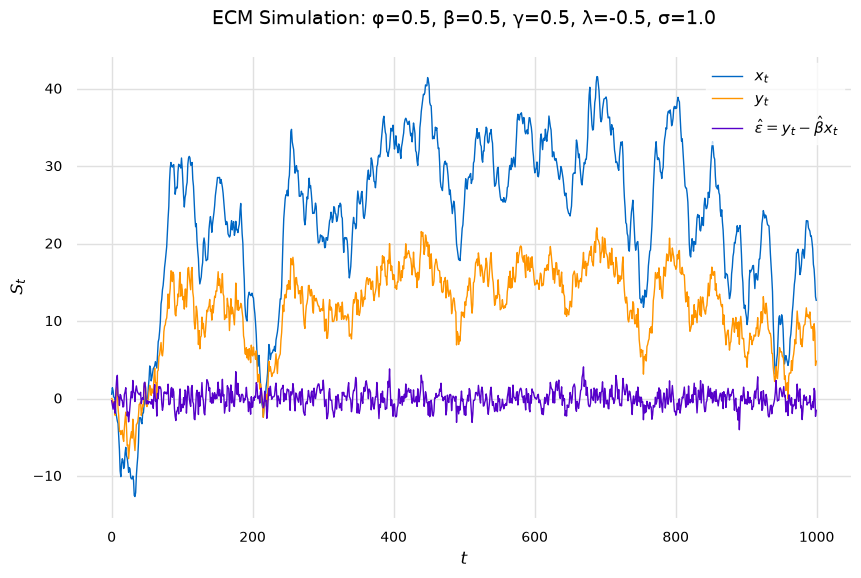

In [4]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [5]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.197       │
├────────────────┼───────────────┤
│ pvalue         │   4.51102e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [6]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "70fe59ef-bc04-4003-b307-3faa11acf81f",
                "label": "$t$",
                "value": -18.197006333473276
            },
            "pval": {
                "test_id": "70fe59ef-bc04-4003-b307-3faa11acf81f",
                "label": "$p-value$",
                "value": 4.511022111622057e-29
            },
            "params": [],
            "sig": {
                "test_id": "70fe59ef-bc04-4003-b307-3faa11acf81f",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "70fe59ef-bc04-4003-b307-3faa11acf81f",
                "label": "$t_L$",
                "value": -2.5679816723029334
            },
            "upper": null,
            "test_id": "70fe59ef-bc04-4003-b307-3faa11acf81f"
        },
  

In [7]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                 2.315e+04
Date:                Sun, 30 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:58:58   Log-Likelihood:                -1557.0
No. Observations:                1000   AIC:                             3118.
Df Residuals:                     998   BIC:                             3128.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0044      0.085      0.053      0.958      -0.161       0.170
x1             0.4999      0.003    152.136      0.000       0.493       0.506
==============================================================================
Omnibus:                        0.172   Durbin-Watson:                   0.998
Prob(Omnibus):                  0.917   Jarque-Bera (JB):                0.097
Skew:                          -0.010   Prob(JB):                        0.953
Kurtosis:                       3.044   Cond. No.                         59.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.004442334928101754,
      "err": 0.08452550590446213,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "396fd59a-6ec0-4905-9585-f2dc420efbf6",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.49985320631394925,
         "err": 0.0032855730038984874,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "396fd59a-6ec0-4905-9585-f2dc420efbf6",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9586634716757728,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "396fd59a-6ec0-4905-9585-f2dc420efbf6",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param

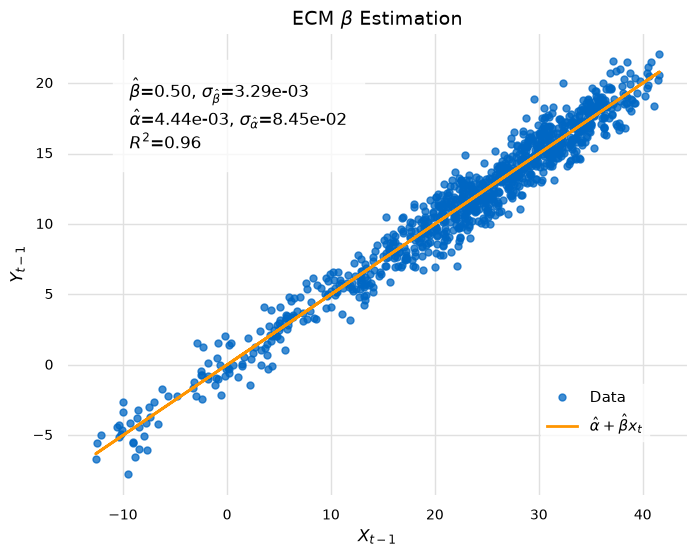

In [9]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [10]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     332.8
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          2.02e-111
Time:                        11:58:58   Log-Likelihood:                -1411.8
No. Observations:                 999   AIC:                             2830.
Df Residuals:                     996   BIC:                             2844.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.032      0.051      0.960      -0.060       0.063
x1             0.5122      0.027     18.832      0.000       0.459       0.566
x2            -0.4995      0.027    -18.186      0.000      -0.553      -0.446
==============================================================================
Omnibus:                        0.690   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.708   Jarque-Bera (JB):                0.725
Skew:                          -0.063   Prob(JB):                        0.696
Kurtosis:                       2.960   Cond. No.                         1.17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.0015957508574820506,
      "err": 0.031507130853346214,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "edd39083-fb81-4e11-9115-e62fe42d5ddd",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5121853319853921,
         "err": 0.027198012646863196,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "edd39083-fb81-4e11-9115-e62fe42d5ddd",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.49947951992300155,
         "err": 0.02746497178425479,
         "est_label": "$\\alpha_2$",
         "err_label": "$\\sigma_{\\alpha_2}$",
         "row": 0,
         "column": 2,
         "order": 0,
         "est_id": "edd39083-fb81-4e11-9115-e62fe42d5ddd",
         "param_type": "OLS_PARAM"
  